Dataset: Air quality data from CPCB for 4 cities (Delhi, Kolkata, Mumbai, Bengaluru) 
covering 2022-2024.
Data was loaded, cleaned and combined in preprocessing files.
This notebook covers EDA, visualization, insights and ML modelling.

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [62]:
df= pd.read_csv(r"C:\Users\DELL\Downloads\AQI_PROJECT\All_combined(sorted).csv", index_col="Timestamp", parse_dates=True)

In [63]:
df.head()

,City,PM2.5,PM10,NO,NO2,NOx,NH3,SO2,CO,Ozone,...,MP-Xylene,AT,RH,WS,WD,RF,TOT-RF,SR,BP,VWS
Timestamp,,,,,,,,,,,,,,,,,,,,,
2022-01-01,Bengaluru,13.50,28.36,18.91,16.08,33.00,2.30,7.01,0.10,18.76,...,0.30,NaN,83.92,0.93,191.38,NaN,NaN,54.71,923.25,0.04
2022-01-01,Delhi,393.56,598.82,214.12,99.19,222.79,41.48,21.34,3.31,9.63,...,NaN,13.97,75.32,0.32,230.10,NaN,0.0,157.49,974.07,NaN
2022-01-01,Kolkata,113.29,190.47,9.32,26.51,35.83,16.48,46.57,0.73,36.97,...,2.00,30.82,75.78,0.20,234.69,0.0,0.0,67.49,999.41,0.00
2022-01-01,Mumbai,52.26,111.27,0.92,8.50,9.42,8.50,22.33,0.77,16.18,...,0.28,25.18,70.19,1.92,147.86,NaN,0.0,0.02,998.24,NaN
2022-01-02,Bengaluru,12.67,27.15,18.92,16.08,33.00,2.30,6.99,0.10,19.68,...,0.30,NaN,93.33,0.93,86.44,NaN,NaN,73.18,921.95,0.07


In [64]:
df.shape

(4384, 25)

In [65]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 4384 entries, 2022-01-01 to 2024-12-31
Data columns (total 25 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   City         4384 non-null   str    
 1   PM2.5        4384 non-null   float64
 2   PM10         4384 non-null   float64
 3   NO           4384 non-null   float64
 4   NO2          4384 non-null   float64
 5   NOx          4384 non-null   float64
 6   NH3          4384 non-null   float64
 7   SO2          4384 non-null   float64
 8   CO           4384 non-null   float64
 9   Ozone        4384 non-null   float64
 10  Benzene      4384 non-null   float64
 11  Toluene      3288 non-null   float64
 12  Xylene       0 non-null      float64
 13  O            0 non-null      float64
 14  Eth-Benzene  3288 non-null   float64
 15  MP-Xylene    3288 non-null   float64
 16  AT           3288 non-null   float64
 17  RH           4384 non-null   float64
 18  WS           4384 non-null   float64
 19 

In [66]:
df.dtypes

City               str
PM2.5          float64
PM10           float64
NO             float64
NO2            float64
NOx            float64
NH3            float64
SO2            float64
CO             float64
Ozone          float64
Benzene        float64
Toluene        float64
Xylene         float64
O              float64
Eth-Benzene    float64
MP-Xylene      float64
AT             float64
RH             float64
WS             float64
WD             float64
RF             float64
TOT-RF         float64
SR             float64
BP             float64
VWS            float64
dtype: object

In [67]:
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df) * 100).round(2)
})
missing[missing['Missing Count'] > 0]

,Missing Count,Missing %
Toluene,1096,25.0
Xylene,4384,100.0
O,4384,100.0
Eth-Benzene,1096,25.0
MP-Xylene,1096,25.0
AT,1096,25.0
RF,3288,75.0
TOT-RF,1096,25.0
VWS,2192,50.0


- Xylene and O are 100% missing across all 4 cities and will be dropped
- RF is 75% missing, present only in Kolkata, not useful for cross city analysis
- VWS is 50% missing, absent in Delhi and Mumbai
- Toluene, Eth-Benzene, MP-Xylene and AT are 25% missing, each absent in one specific city
- TOT-RF is 25% missing, absent only in Bengaluru

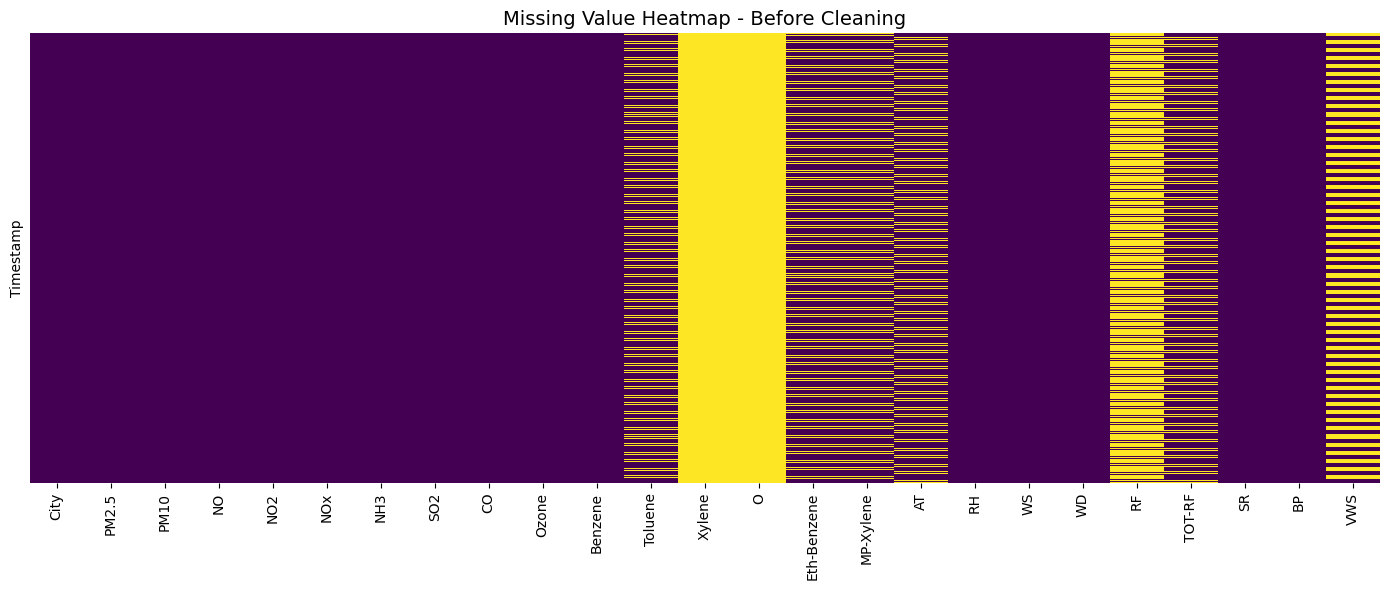

In [68]:
plt.figure(figsize=(14, 6))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Value Heatmap - Before Cleaning', fontsize=14)
plt.tight_layout()
plt.show()

- Purple indicates data present, Yellow indicates missing values
- Xylene and O appear fully yellow confirming 100% absence
- Striped pattern in Toluene, AT, Eth-Benzene columns shows city specific missing blocks
- Core pollutant columns PM2.5, PM10, NO2, SO2, CO are fully purple meaning no missing values

In [69]:
df.describe()

,PM2.5,PM10,NO,NO2,NOx,NH3,SO2,CO,Ozone,Benzene,...,MP-Xylene,AT,RH,WS,WD,RF,TOT-RF,SR,BP,VWS
count,4384.000000,4384.000000,4384.000000,4384.000000,4384.000000,4384.000000,4384.000000,4384.000000,4384.000000,4384.000000,...,3288.000000,3288.000000,4384.000000,4384.000000,4384.000000,1096.000000,3288.000000,4384.000000,4384.000000,2192.000000
mean,61.317324,141.262055,37.147621,36.689062,58.245561,25.746512,14.132589,1.028175,25.770408,2.658285,...,1.048364,27.031846,71.563581,1.228757,157.505484,0.034197,0.070289,125.539995,932.075584,-0.072331
std,65.790287,132.151978,56.357350,36.338969,63.946716,26.148955,12.665639,0.910463,19.900385,4.658600,...,1.446796,5.834100,15.219299,1.812053,70.974736,0.112715,1.098445,179.054782,104.301942,0.462749
min,2.250000,9.160000,0.400000,0.050000,0.000000,0.140000,0.010000,0.000000,0.040000,0.000000,...,0.050000,8.250000,23.800000,0.040000,1.750000,0.000000,-0.010000,0.000000,702.000000,-1.220000
25%,20.955000,52.330000,9.547500,14.557500,22.357500,11.577500,7.890000,0.440000,10.830000,0.210000,...,0.380000,24.137500,61.200000,0.570000,87.880000,0.000000,0.000000,32.325000,823.300000,-0.140000
50%,38.770000,92.405000,12.680000,22.645000,34.630000,19.700000,10.590000,0.740000,20.825000,0.820000,...,0.740000,27.480000,73.890000,0.770000,172.280000,0.000000,0.000000,90.230000,993.560000,-0.010000
75%,75.245000,179.495000,33.965000,45.677500,59.875000,32.395000,17.400000,1.350000,33.600000,3.570000,...,0.880000,30.820000,82.742500,1.110000,218.190000,0.000000,0.000000,155.697500,1007.725000,0.030000
max,672.880000,838.520000,438.500000,315.540000,468.540000,345.880000,185.200000,8.710000,185.190000,48.320000,...,12.750000,56.950000,99.750000,10.980000,359.000000,1.560000,39.200000,1293.570000,1095.650000,11.560000


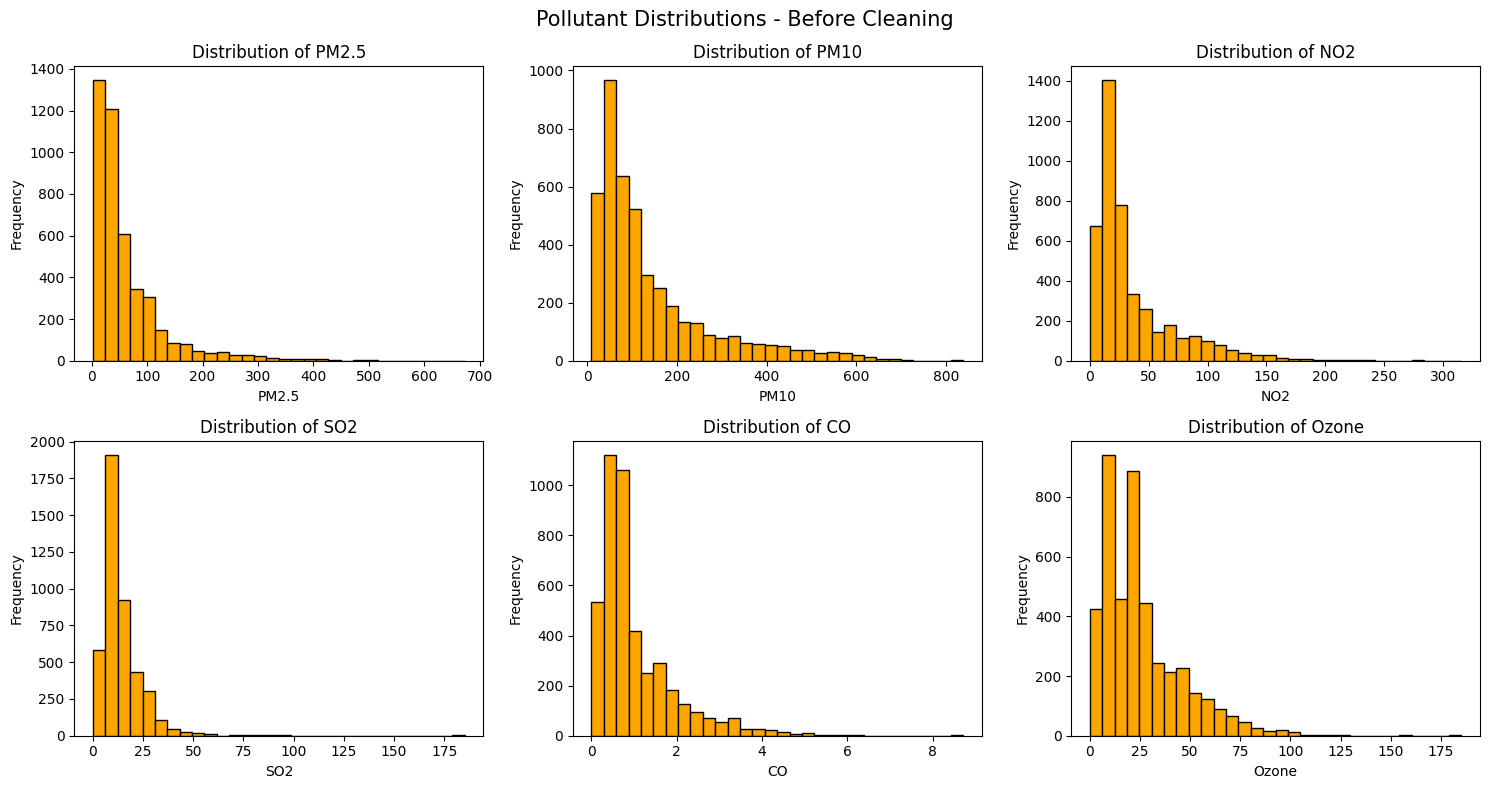

In [70]:
key_cols = ['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'Ozone']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(key_cols):
    axes[i].hist(df[col], bins=30, color='orange', edgecolor='black')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.suptitle('Pollutant Distributions - Before Cleaning', fontsize=15)
plt.tight_layout()
plt.show()

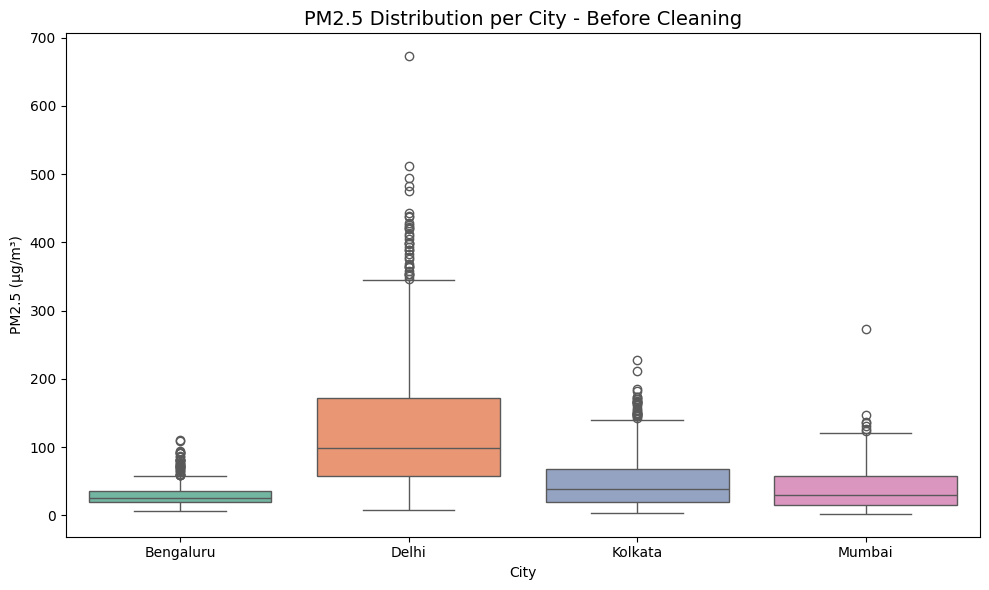

In [71]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='City', y='PM2.5',hue='City', palette='Set2', legend=False)
plt.title('PM2.5 Distribution per City - Before Cleaning', fontsize=14)
plt.xlabel('City')
plt.ylabel('PM2.5 (µg/m³)')
plt.tight_layout()
plt.show()

In [72]:
df = df.drop(columns=["Xylene","O"]) 

In [73]:
df = df.drop(columns=["RF", "VWS"])

- Xylene and O dropped due to 100% missing data across all cities
- RF dropped due to 75% missing, only Kolkata had data making it unreliable for comparison
- VWS dropped due to 50% missing, absent in 2 out of 4 cities

In [74]:
#Full EDA(After cleaning)
df.isnull().sum()

City              0
PM2.5             0
PM10              0
NO                0
NO2               0
NOx               0
NH3               0
SO2               0
CO                0
Ozone             0
Benzene           0
Toluene        1096
Eth-Benzene    1096
MP-Xylene      1096
AT             1096
RH                0
WS                0
WD                0
TOT-RF         1096
SR                0
BP                0
dtype: int64

In [75]:
df.groupby("City").mean(numeric_only=True)

,PM2.5,PM10,NO,NO2,NOx,NH3,SO2,CO,Ozone,Benzene,Toluene,Eth-Benzene,MP-Xylene,AT,RH,WS,WD,TOT-RF,SR,BP
City,,,,,,,,,,,,,,,,,,,,
Bengaluru,28.603412,63.407281,11.248850,25.368896,37.122345,18.854863,8.863485,0.796515,23.934252,0.647235,1.618823,1.195940,0.632199,NaN,74.024288,2.071031,203.803339,NaN,103.724881,836.316870
Delhi,127.708631,305.717874,88.231141,78.745620,117.836241,38.318276,17.825401,2.017245,31.964617,4.080958,33.806633,NaN,NaN,26.553604,60.134909,0.939425,139.452318,0.000000,235.169626,874.971597
Kolkata,49.280027,106.524297,11.934151,17.724918,22.986889,25.988376,14.232290,0.656177,38.852327,5.834644,8.937984,1.417436,1.564571,27.561688,70.023376,0.832190,186.865192,0.210867,137.101880,1010.203786
Mumbai,39.677226,89.398768,37.176341,24.916816,55.036770,19.824535,15.609179,0.642765,8.330438,0.070301,NaN,0.732117,0.948321,26.980246,82.071752,1.072381,99.901086,0.000000,26.163595,1006.810082


In [76]:
df.groupby("City").median(numeric_only=True)

,PM2.5,PM10,NO,NO2,NOx,NH3,SO2,CO,Ozone,Benzene,Toluene,Eth-Benzene,MP-Xylene,AT,RH,WS,WD,TOT-RF,SR,BP
City,,,,,,,,,,,,,,,,,,,,
Bengaluru,25.62,55.545,10.000,24.45,36.225,13.85,8.125,0.730,21.490,0.410,1.45,1.660,0.750,NaN,76.11,0.88,222.46,NaN,86.845,792.625
Delhi,99.39,294.610,75.870,73.92,106.980,35.85,16.960,1.820,24.935,2.680,28.70,NaN,NaN,29.00,60.16,0.78,123.20,0.0,141.435,971.650
Kolkata,38.27,88.040,10.445,16.66,20.680,23.65,11.140,0.580,37.650,3.855,7.61,0.795,1.015,28.67,71.29,0.72,198.68,0.0,126.370,1007.110
Mumbai,29.33,75.490,14.505,16.18,30.800,9.43,10.350,0.385,10.585,0.060,NaN,0.450,0.590,26.32,81.85,0.70,84.05,0.0,0.030,1007.755


In [77]:
#Standard deviation
df.groupby("City").std(numeric_only=True)

,PM2.5,PM10,NO,NO2,NOx,NH3,SO2,CO,Ozone,Benzene,Toluene,Eth-Benzene,MP-Xylene,AT,RH,WS,WD,TOT-RF,SR,BP
City,,,,,,,,,,,,,,,,,,,,
Bengaluru,14.253963,36.526792,4.905159,9.994721,9.589995,11.729621,3.492618,0.650006,10.413783,0.516686,0.613521,0.718881,0.275251,NaN,14.412649,3.253949,60.285504,NaN,112.598111,85.923157
Delhi,92.674046,153.321239,61.351910,41.227741,65.846210,22.239592,10.058708,0.959871,24.045513,5.706556,28.549497,NaN,NaN,7.787251,14.320681,0.582529,74.335925,0.00000,287.265627,108.471093
Kolkata,37.931653,69.973997,9.653721,9.821136,10.859636,15.856820,9.932610,0.284571,18.919246,5.579883,5.775319,1.657089,1.595400,4.068966,12.464318,0.567816,41.581883,1.89533,72.659827,15.053350
Mumbai,31.592444,55.938096,70.088694,31.500995,81.035826,40.155078,19.658333,0.757065,4.807685,0.163466,NaN,1.601590,1.792298,4.945906,10.453991,0.957840,51.171173,0.00000,72.983005,5.303835


In [78]:
df.skew(numeric_only=True)

PM2.5           2.662680
PM10            1.749143
NO              2.882285
NO2             2.076614
NOx             2.519459
NH3             5.146895
SO2             6.253010
CO              2.004164
Ozone           1.519550
Benzene         4.492523
Toluene         2.910267
Eth-Benzene     3.750853
MP-Xylene       4.168113
AT              0.034986
RH             -0.442254
WS              4.553446
WD             -0.126468
TOT-RF         26.032085
SR              3.695090
BP             -0.932729
dtype: float64

- Most pollutants show positive skewness meaning occasional extreme pollution spikes pull the distribution right
- SO2 and NH3 have very high skewness suggesting rare but intense emission events
- AT and RH are nearly symmetric meaning temperature and humidity are relatively stable

In [79]:
df.groupby("City")["PM2.5"].mean().sort_values(ascending=False)

City
Delhi        127.708631
Kolkata       49.280027
Mumbai        39.677226
Bengaluru     28.603412
Name: PM2.5, dtype: float64

In [80]:
pm25_mean = df.groupby("City")["PM2.5"].mean().reset_index()
pm25_mean

,City,PM2.5
0,Bengaluru,28.603412
1,Delhi,127.708631
2,Kolkata,49.280027
3,Mumbai,39.677226


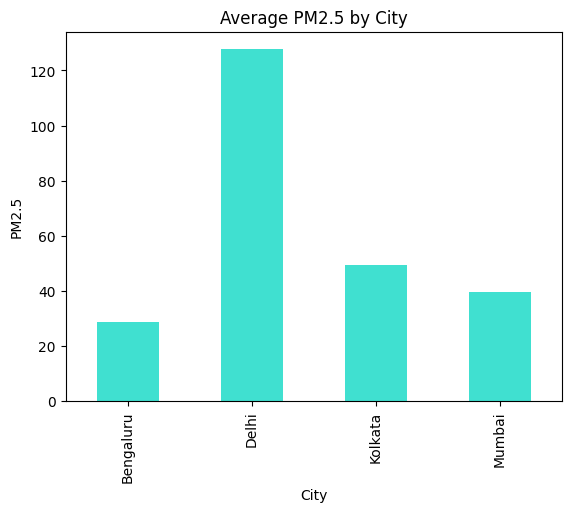

In [81]:
pm25_mean.set_index("City")["PM2.5"].plot(kind="bar", color='turquoise')
plt.title("Average PM2.5 by City")
plt.ylabel("PM2.5")
plt.show()

- Delhi has the highest average PM2.5 at 127.7 ug/m3, nearly 3x higher than Kolkata (49.3) and Mumbai (39.7)
- Bengaluru is the cleanest city with average PM2.5 of 28.6 ug/m3
- All 4 cities exceed the WHO safe limit of 15 ug/m3

In [82]:
df.corr(numeric_only=True)["PM2.5"].sort_values(ascending=False)

PM2.5          1.000000
PM10           0.893866
CO             0.568710
NO2            0.545655
NOx            0.537235
Toluene        0.532712
NO             0.508822
MP-Xylene      0.300668
Benzene        0.295003
SR             0.256259
NH3            0.225126
SO2            0.146732
Eth-Benzene    0.142477
Ozone          0.000864
TOT-RF        -0.047083
WS            -0.094786
WD            -0.109334
BP            -0.168829
RH            -0.306529
AT            -0.406481
Name: PM2.5, dtype: float64

- PM2.5 and PM10 have very strong positive correlation (0.89) confirming shared pollution sources
- CO, NO2, NOx show moderate positive correlation with PM2.5 indicating vehicular emissions as a major source
- Temperature (AT) has negative correlation (-0.41) meaning colder weather leads to higher PM2.5
- Humidity (RH) also negatively correlated (-0.31) with PM2.5
- Wind speed (WS) shows negative correlation (-0.09) as stronger winds disperse pollutants

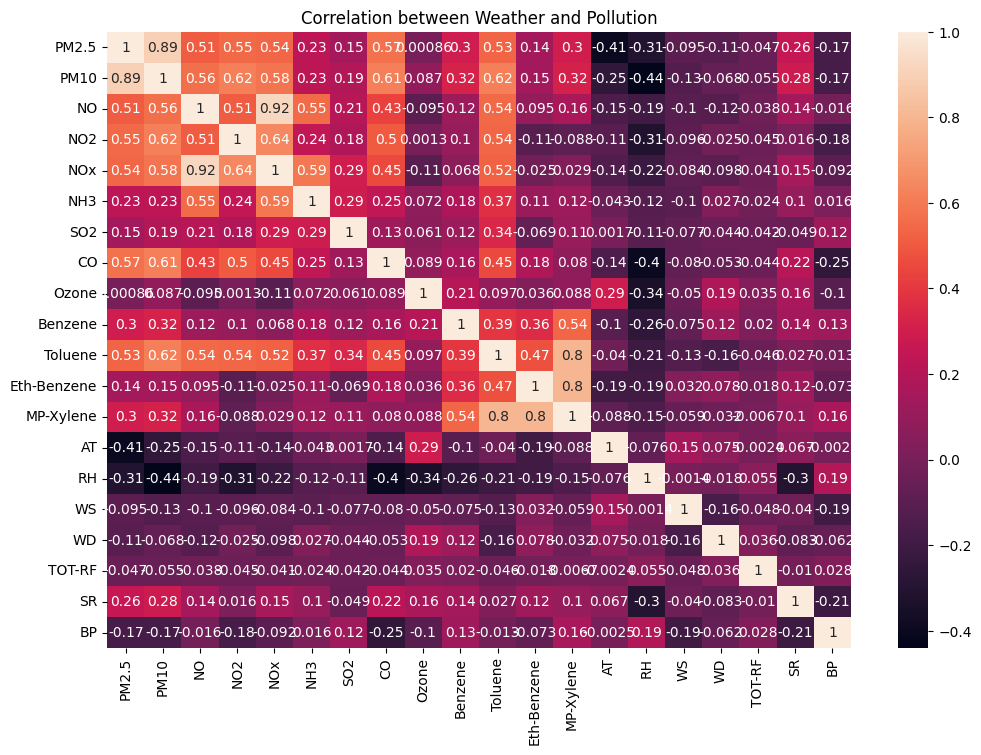

In [83]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation between Weather and Pollution")
plt.show()

In [84]:
df_plot = df.reset_index()

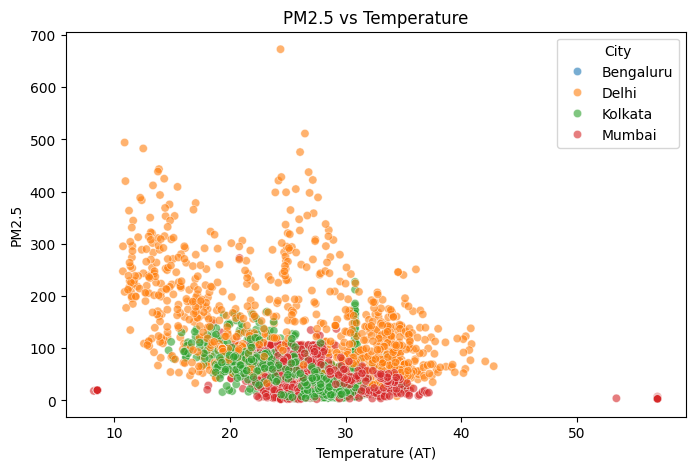

In [85]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df_plot,
    x="AT",
    y="PM2.5",
    hue="City",
    alpha=0.6
)
plt.title("PM2.5 vs Temperature")
plt.xlabel("Temperature (AT)")
plt.ylabel("PM2.5")
plt.show()

Lower temperatures correspond to higher PM2.5 levels due to temperature inversion trapping pollutants near ground.

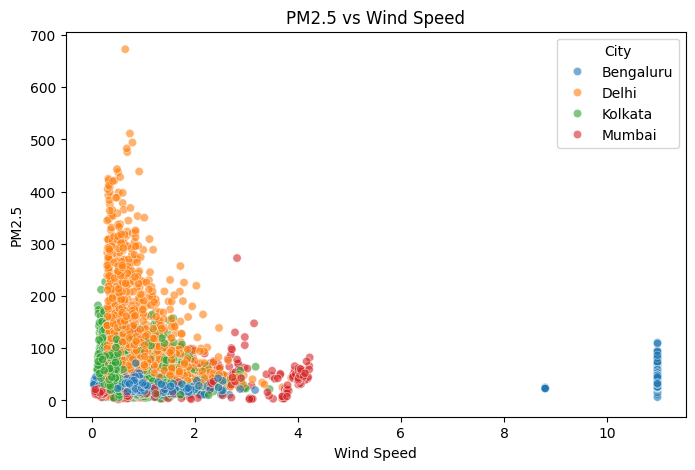

In [86]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df_plot,
    x="WS",
    y="PM2.5",
    hue="City",
    alpha=0.6
)
plt.title("PM2.5 vs Wind Speed")
plt.xlabel("Wind Speed")
plt.ylabel("PM2.5")
plt.show()

Higher wind speeds lead to lower PM2.5 as wind disperses pollutants.

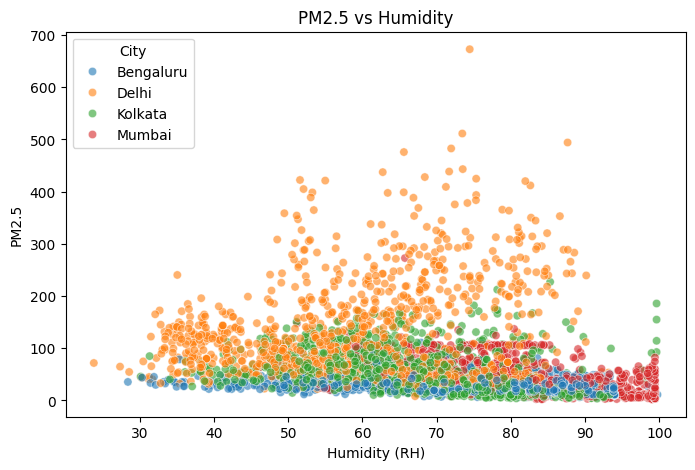

In [87]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df_plot,
    x="RH",
    y="PM2.5",
    hue="City",
    alpha=0.6
)
plt.title("PM2.5 vs Humidity")
plt.xlabel("Humidity (RH)")
plt.ylabel("PM2.5")
plt.show()

High humidity shows slightly lower PM2.5 as moisture helps settle particles.

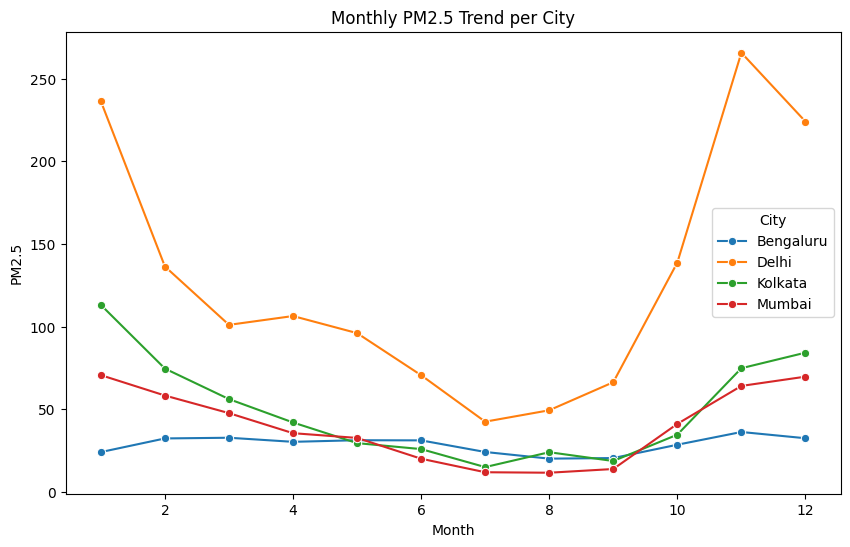

In [88]:
#Monthly trend 
df_plot["Month"] = df_plot["Timestamp"].dt.month
monthly = df_plot.groupby(["Month","City"])["PM2.5"].mean().reset_index()
plt.figure(figsize=(10,6))
sns.lineplot(
    data=monthly,
    x="Month",
    y="PM2.5",
    hue="City",
    marker="o"
)
plt.title("Monthly PM2.5 Trend per City")
plt.show()

- PM2.5 peaks in January (111 ug/m3) and November (110 ug/m3) due to winter temperature inversions and crop burning
- Lowest levels in July (23.4 ug/m3) during monsoon when rainfall washes pollutants
- Clear seasonal cycle visible across all cities

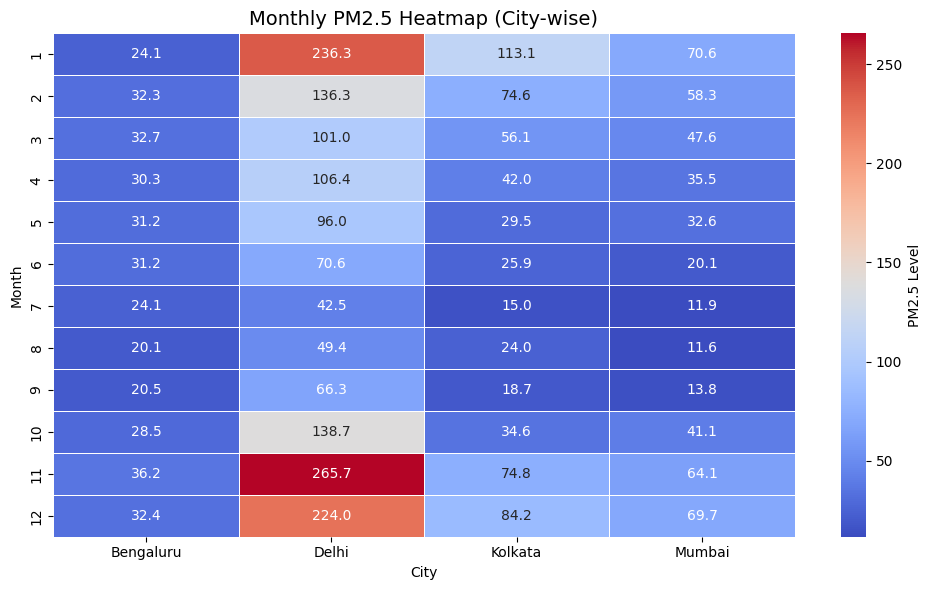

In [89]:
#Monthly Heatmap
pivot = df_plot.pivot_table(
    values="PM2.5",
    index="Month",
    columns="City",
    aggfunc="mean"
)
plt.figure(figsize=(10,6))
sns.heatmap(
    pivot,
    annot=True,
    cmap="coolwarm",
    fmt=".1f",          # removes scientific notation
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "PM2.5 Level"}
)
plt.title("Monthly PM2.5 Heatmap (City-wise)", fontsize=14)
plt.xlabel("City")
plt.ylabel("Month")
plt.tight_layout()
plt.show()

- Winter months (Nov-Jan) show dark red across all cities confirming seasonal pollution pattern
- Monsoon months (Jun-Sep) show consistently lighter shades indicating cleaner air
- Delhi remains darkest throughout the year compared to other cities

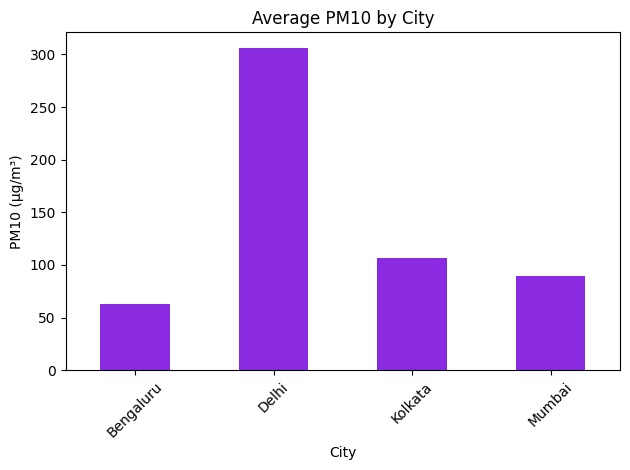

In [90]:
df.groupby("City")["PM10"].mean().plot(kind="bar", color='blueviolet')
plt.title("Average PM10 by City")
plt.ylabel("PM10 (µg/m³)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

- Delhi's average PM10 (305.7 ug/m3) is nearly 3x Kolkata (106.5) confirming severe particulate pollution
- Order matches PM2.5 ranking: Delhi > Kolkata > Mumbai > Bengaluru

In [91]:
df.groupby("City").apply(lambda x: x.mode().iloc[0], include_groups=False)

,PM2.5,PM10,NO,NO2,NOx,NH3,SO2,CO,Ozone,Benzene,Toluene,Eth-Benzene,MP-Xylene,AT,RH,WS,WD,TOT-RF,SR,BP
City,,,,,,,,,,,,,,,,,,,,
Bengaluru,29.53,52.88,9.65,24.64,37.42,13.85,6.64,0.74,21.74,0.41,1.45,1.67,0.88,NaN,74.29,10.98,66.04,NaN,40.05,707.74
Delhi,99.39,217.33,38.48,32.17,70.69,8.77,19.52,3.40,30.56,6.34,28.70,NaN,NaN,19.35,49.36,0.30,87.88,0.0,143.21,823.30
Kolkata,26.08,67.57,8.57,16.73,16.77,15.59,9.33,0.48,41.88,3.56,7.64,0.32,2.55,30.82,78.84,0.24,245.83,0.0,140.13,999.41
Mumbai,106.02,17.00,4.72,73.54,0.00,4.24,8.37,0.27,10.71,0.00,NaN,0.45,0.79,56.95,99.41,0.61,81.88,0.0,0.01,998.24


In [92]:
df.groupby("City").var(numeric_only=True)

,PM2.5,PM10,NO,NO2,NOx,NH3,SO2,CO,Ozone,Benzene,Toluene,Eth-Benzene,MP-Xylene,AT,RH,WS,WD,TOT-RF,SR,BP
City,,,,,,,,,,,,,,,,,,,,
Bengaluru,203.175461,1334.206520,24.060587,99.894451,91.968002,137.584008,12.198383,0.422508,108.446875,0.266964,0.376408,0.516790,0.075763,NaN,207.724464,10.588186,3634.342003,NaN,12678.334619,7382.788887
Delhi,8588.478875,23507.402432,3764.056920,1699.726599,4335.723407,494.599462,101.177610,0.921353,578.186715,32.564777,815.073800,NaN,NaN,60.641286,205.081897,0.339340,5525.829686,0.000000,82521.540415,11765.977918
Kolkata,1438.810284,4896.360265,93.194329,96.454709,117.931704,251.438729,98.656733,0.080981,357.937864,31.135096,33.354307,2.745943,2.545300,16.556486,155.359224,0.322415,1729.052999,3.592277,5279.450429,226.603332
Mumbai,998.082524,3129.070638,4912.425075,992.312680,6566.805144,1612.430304,386.450059,0.573147,23.113840,0.026721,NaN,2.565091,3.212333,24.461986,109.285938,0.917457,2618.488972,0.000000,5326.518993,28.130663


- Delhi shows highest variance in PM2.5 indicating highly inconsistent pollution levels throughout the year
- Bengaluru shows lowest variance confirming stable and consistently clean air quality

In [93]:
Q1 = df.select_dtypes(include='number').quantile(0.25)
Q3 = df.select_dtypes(include='number').quantile(0.75)
IQR = Q3 - Q1

outliers = ((df.select_dtypes(include='number') < (Q1 - 1.5 * IQR)) | 
            (df.select_dtypes(include='number') > (Q3 + 1.5 * IQR))).sum()

pd.DataFrame({'Outlier Count': outliers, 
              'Outlier %': (outliers/len(df)*100).round(2)})

,Outlier Count,Outlier %
PM2.5,342,7.80
PM10,364,8.30
NO,715,16.31
NO2,413,9.42
NOx,623,14.21
NH3,194,4.43
SO2,209,4.77
CO,296,6.75
Ozone,196,4.47
Benzene,251,5.73


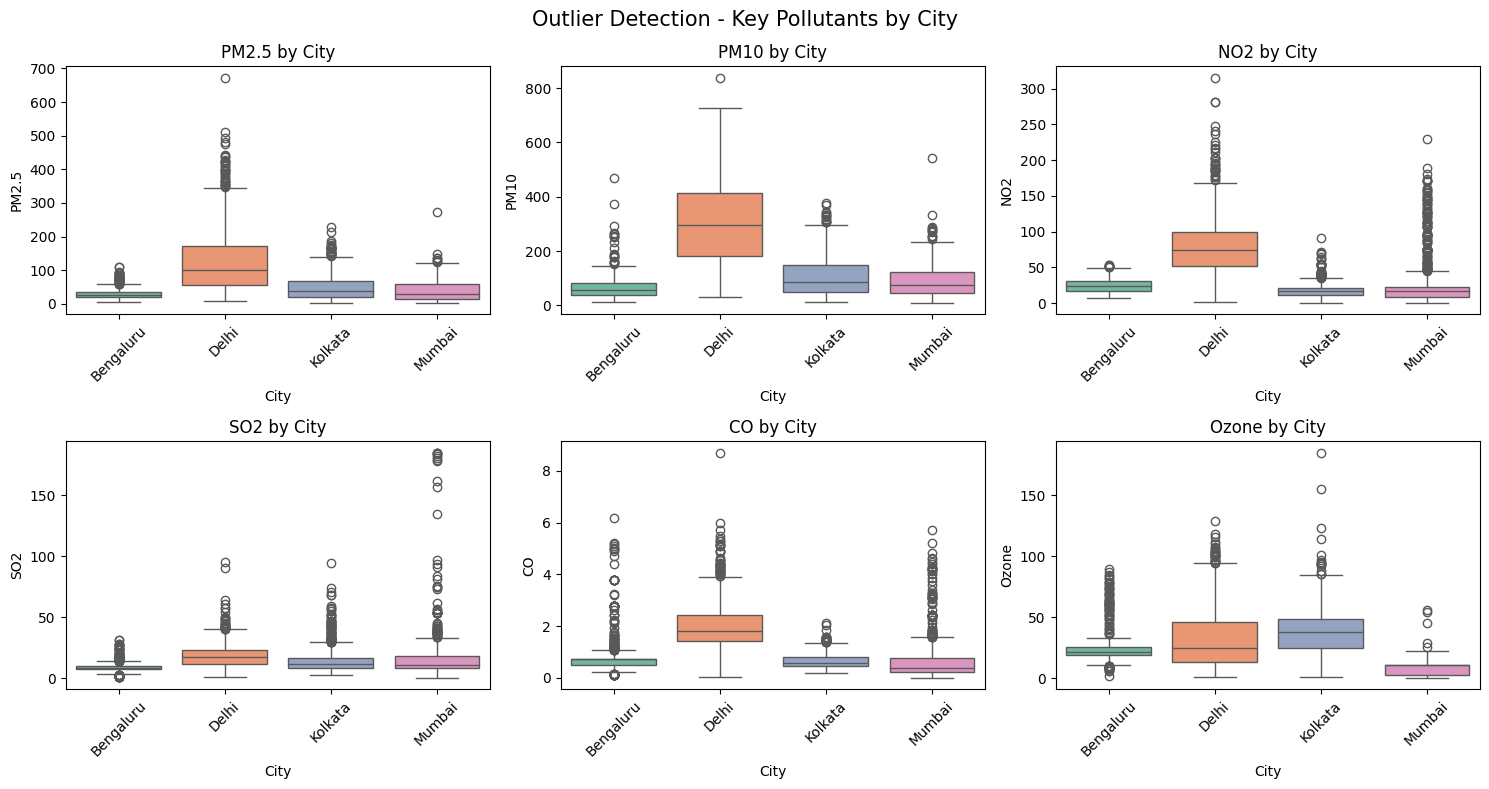

In [94]:
key_cols = ['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'Ozone']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(key_cols):
    sns.boxplot(
        data=df,
        x='City',
        y=col,
        hue='City',    
        palette='Set2',
        ax=axes[i],
        legend=False           
    )
    axes[i].set_title(f'{col} by City')
    axes[i].set_xlabel('City')
    axes[i].set_ylabel(col)
    axes[i].tick_params(axis='x', rotation=45)
plt.suptitle('Outlier Detection - Key Pollutants by City', fontsize=15)
plt.tight_layout()
plt.show()

- NH3, SO2 and Benzene show high skewness indicating presence of extreme outlier events
- Delhi shows most outliers in PM2.5 and PM10 due to severe pollution episodes in winter
- Outliers are real pollution spike events, not data errors, so they are retained

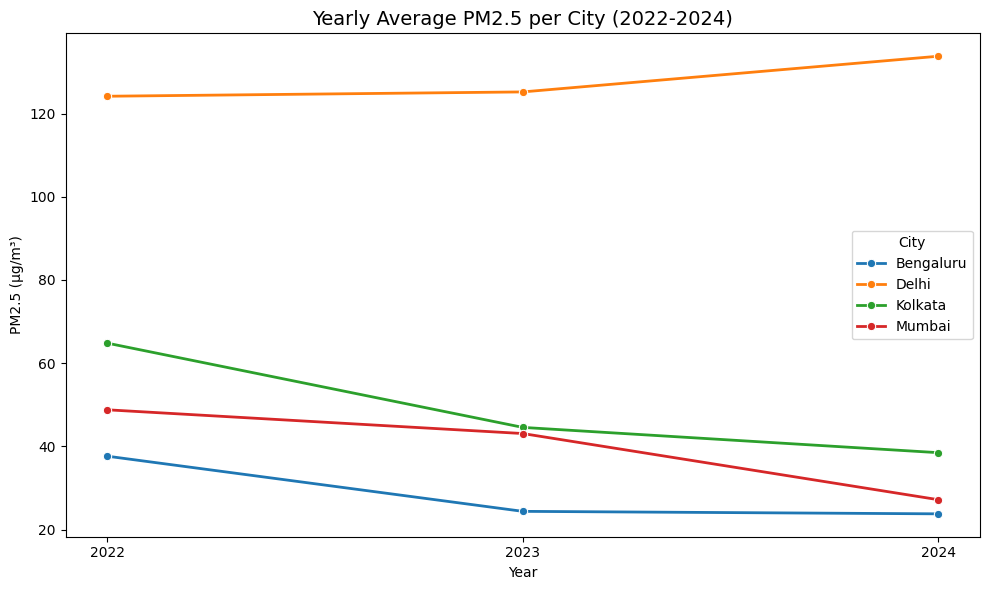

In [95]:
df['Year'] = df.index.year
yearly = df.groupby(['Year', 'City'])['PM2.5'].mean().reset_index()
plt.figure(figsize=(10, 6))
sns.lineplot(data=yearly, x='Year', y='PM2.5', hue='City', marker='o', linewidth=2)
plt.title('Yearly Average PM2.5 per City (2022-2024)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('PM2.5 (µg/m³)')
plt.xticks([2022, 2023, 2024])
plt.tight_layout()
plt.show()

- Delhi shows slight improvement from 2022 to 2024 but remains far above safe levels
- Bengaluru remains consistently the least polluted across all 3 years
- No city shows dramatic year on year improvement suggesting systemic pollution issues

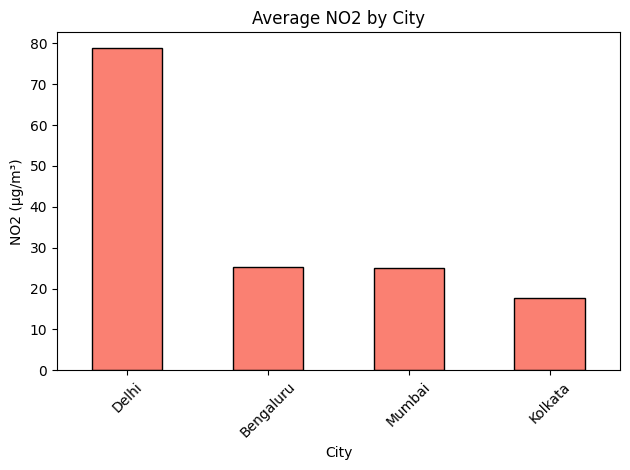

In [96]:
df.groupby('City')['NO2'].mean().sort_values(ascending=False).plot(kind='bar', color='salmon', edgecolor='black')
plt.title('Average NO2 by City')
plt.ylabel('NO2 (µg/m³)')
plt.xlabel('City')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

- Delhi leads NO2 levels (78.7 ug/m3) indicating heavy vehicular and industrial emissions
- Kolkata has lowest NO2 (17.7 ug/m3) despite being a large metro city

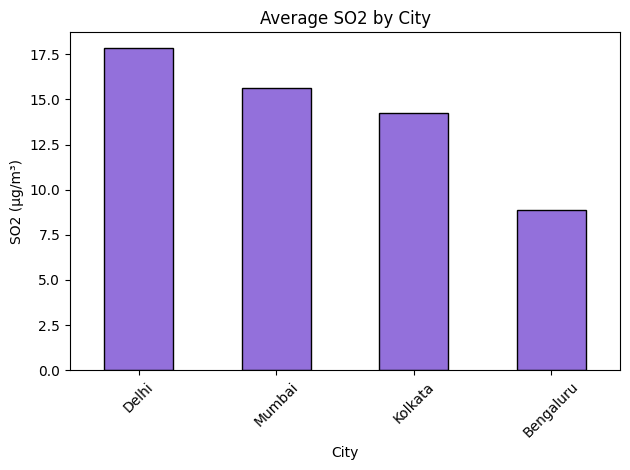

In [97]:
df.groupby('City')['SO2'].mean().sort_values(ascending=False).plot(kind='bar', color='mediumpurple', edgecolor='black')
plt.title('Average SO2 by City')
plt.ylabel('SO2 (µg/m³)')
plt.xlabel('City')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

- Delhi has highest SO2 (17.8 ug/m3) followed closely by Mumbai (15.6) and Kolkata (14.2)
- Bengaluru has lowest SO2 (8.9 ug/m3) suggesting fewer coal based industries

- PM2.5 is used as the target variable as a proxy for AQI since it is the 
dominant pollutant in India's AQI calculation and has the strongest 
influence on overall air quality levels.
- Features include both pollution indicators and meteorological variables
to align with the objective of studying weather influence on air quality.
80% data used for training and 20% for testing.

In [98]:
features = ['PM10', 'NO2', 'NOx', 'NO', 'NH3', 'SO2', 
            'CO', 'Ozone', 'RH', 'WS', 'WD', 'SR', 'BP']
target = 'PM2.5'

X = df[features]
y = df[target]

print('Features shape:', X.shape)
print('Target shape:', y.shape)

Features shape: (4384, 13)
Target shape: (4384,)


In [99]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print('Training size:', X_train.shape)
print('Testing size:', X_test.shape)

Training size: (3507, 13)
Testing size: (877, 13)


Model 1- Multiple Linear Regression

In [100]:
from sklearn.linear_model import LinearRegression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train);

In [101]:
y_pred_lr = lr_model.predict(X_test)

In [102]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
print("Linear Regression Performance:")
print("MAE :", mean_absolute_error(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("R²  :", r2_score(y_test, y_pred_lr))

Linear Regression Performance:
MAE : 17.7547621405308
RMSE: 28.944411277125052
R²  : 0.8223454567549061


- Linear Regression establishes a baseline for prediction
- Higher R² means model explains more variance in PM2.5
- MAE shows average prediction error in ug/m3

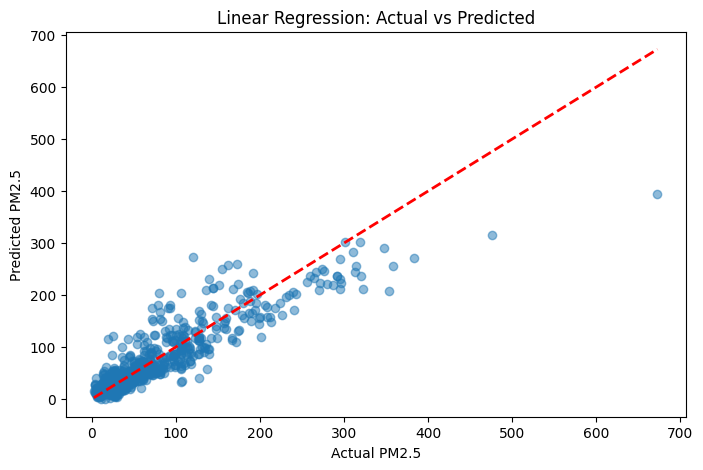

In [103]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred_lr, alpha=0.5)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linestyle='--',
    linewidth=2
)

plt.xlabel("Actual PM2.5")
plt.ylabel("Predicted PM2.5")
plt.title("Linear Regression: Actual vs Predicted")

plt.show()

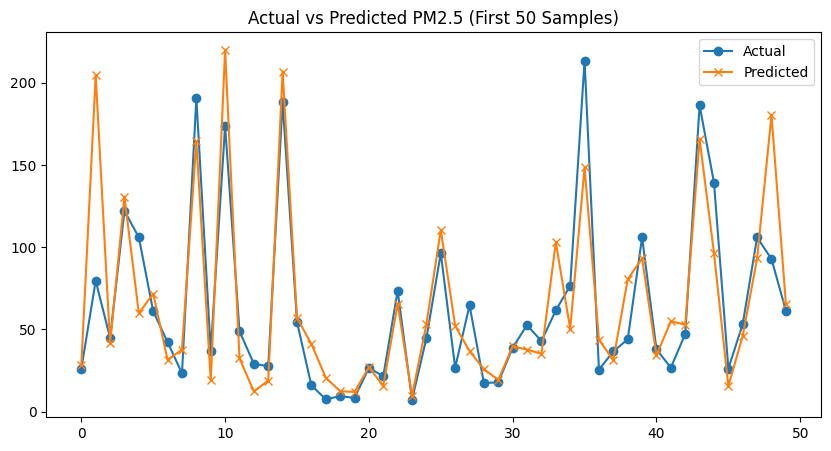

In [104]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values[:50], label="Actual", marker='o')
plt.plot(y_pred_lr[:50], label="Predicted", marker='x')
plt.legend()
plt.title("Actual vs Predicted PM2.5 (First 50 Samples)")
plt.show()

In [105]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr_model.coef_
})

coef_df.sort_values(by="Coefficient", ascending=False)

,Feature,Coefficient
6,CO,3.667988
9,WS,0.475865
8,RH,0.458979
0,PM10,0.458081
2,NOx,0.136253
4,NH3,0.068178
11,SR,0.005288
12,BP,-0.005145
10,WD,-0.034417
1,NO2,-0.048638


Model 2- Random Forest Regression

In [106]:
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

In [107]:
print("Random Forest Performance:")
print("MAE :", mean_absolute_error(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("R²  :", r2_score(y_test, y_pred_rf))

Random Forest Performance:
MAE : 9.240922805017101
RMSE: 19.27791686106672
R²  : 0.9211925848130917


- Random Forest captures non-linear relationships between features
- Feature importance shows which variables contribute most to PM2.5 prediction
- PM10 and CO are expected to be top contributors

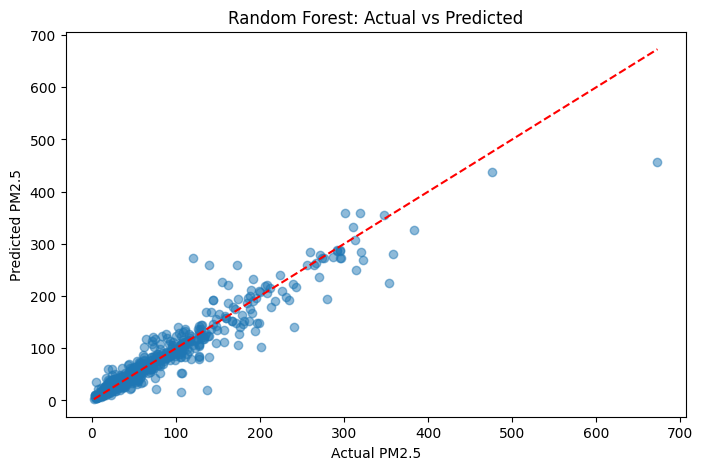

In [108]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred_rf, alpha=0.5)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linestyle='--'
)
plt.xlabel("Actual PM2.5")
plt.ylabel("Predicted PM2.5")
plt.title("Random Forest: Actual vs Predicted")

plt.show()

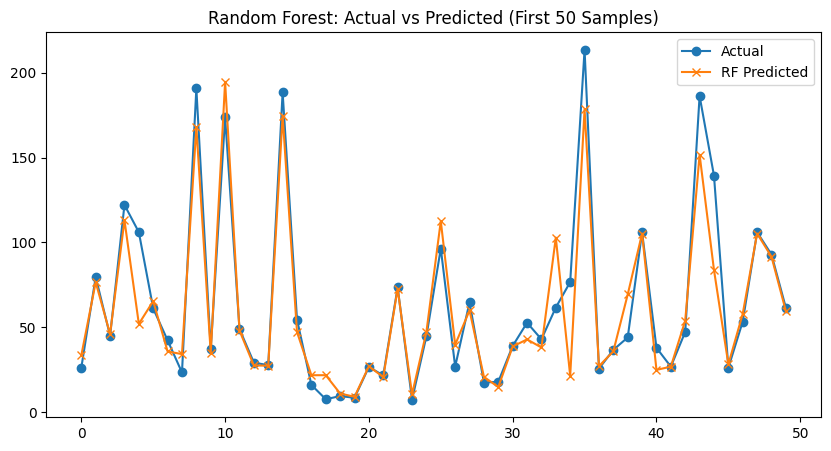

In [109]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values[:50], label="Actual", marker='o')
plt.plot(y_pred_rf[:50], label="RF Predicted", marker='x')
plt.legend()
plt.title("Random Forest: Actual vs Predicted (First 50 Samples)")
plt.show()

In [110]:
rf_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

rf_importance.sort_values(by="Importance", ascending=False)

,Feature,Importance
0,PM10,0.825495
8,RH,0.040170
7,Ozone,0.022709
6,CO,0.016130
11,SR,0.015408
12,BP,0.015071
9,WS,0.010772
5,SO2,0.010750
1,NO2,0.010717
10,WD,0.010488


Model 3- KNN Model

In [111]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [112]:
from sklearn.neighbors import KNeighborsRegressor
knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)
y_pred_knn = knn_model.predict(X_test_scaled)

In [113]:
print("KNN Performance:")
print("MAE :", mean_absolute_error(y_test, y_pred_knn))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_knn)))
print("R²  :", r2_score(y_test, y_pred_knn))

KNN Performance:
MAE : 11.573233751425315
RMSE: 22.0744438201816
R²  : 0.8966700028462041


- KNN predicts based on similarity to nearest data points
- StandardScaler applied before KNN since it is distance based and sensitive to feature scale

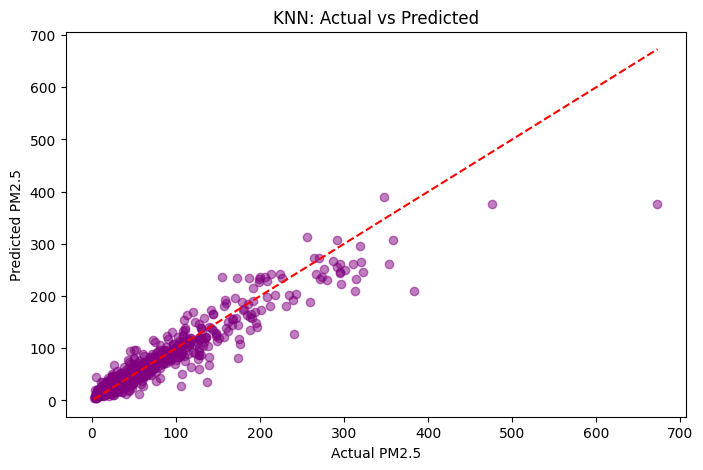

In [114]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred_knn, alpha=0.5, color='purple')
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linestyle='--'
)
plt.xlabel("Actual PM2.5")
plt.ylabel("Predicted PM2.5")
plt.title("KNN: Actual vs Predicted")
plt.show()

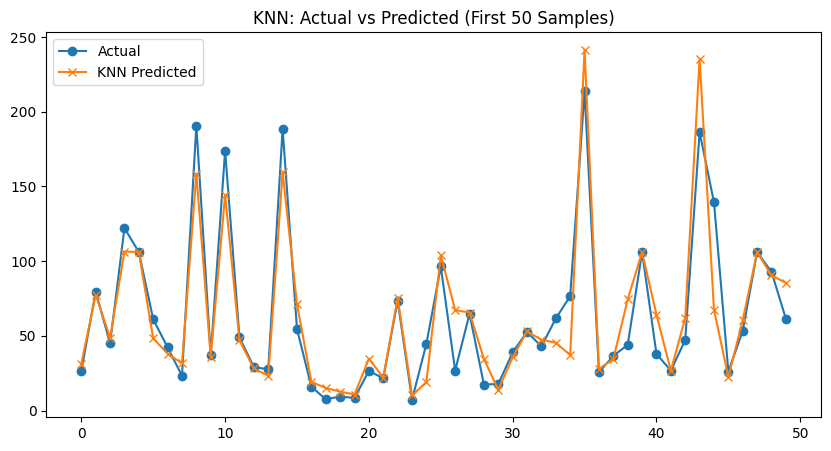

In [115]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values[:50], label="Actual", marker='o')
plt.plot(y_pred_knn[:50], label="KNN Predicted", marker='x')
plt.legend()
plt.title("KNN: Actual vs Predicted (First 50 Samples)")
plt.show()

Comparisions

In [116]:
comparison = pd.DataFrame({
    "Model": ["Multiple Linear Regression", "Random Forest", "KNN"],
    "MAE": [
        mean_absolute_error(y_test, y_pred_lr),
        mean_absolute_error(y_test, y_pred_rf),
        mean_absolute_error(y_test, y_pred_knn)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        np.sqrt(mean_squared_error(y_test, y_pred_rf)),
        np.sqrt(mean_squared_error(y_test, y_pred_knn))
    ],
    "R² Score": [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_rf),
        r2_score(y_test, y_pred_knn)
    ]
})
comparison

,Model,MAE,RMSE,R² Score
0,Multiple Linear Regression,17.754762,28.944411,0.822345
1,Random Forest,9.240923,19.277917,0.921193
2,KNN,11.573234,22.074444,0.896670


- Random Forest outperforms both Linear Regression and KNN across all metrics
- Lower MAE and RMSE means predictions are closer to actual values
- Higher R² means better overall fit to the data

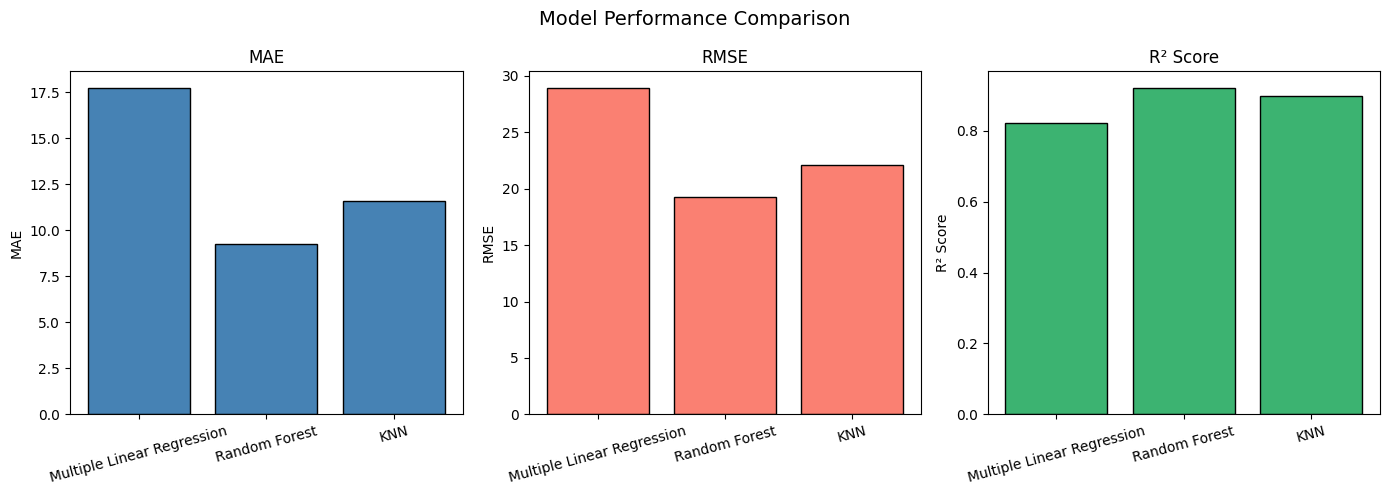

In [117]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
metrics = ['MAE', 'RMSE', 'R² Score']
colors = ['steelblue', 'salmon', 'mediumseagreen']
for i, metric in enumerate(metrics):
    axes[i].bar(comparison['Model'], comparison[metric], color=colors[i], edgecolor='black')
    axes[i].set_title(metric)
    axes[i].set_ylabel(metric)
    axes[i].tick_params(axis='x', rotation=15)
plt.suptitle('Model Performance Comparison', fontsize=14)
plt.tight_layout()
plt.show()

In [118]:
best_model = comparison.loc[comparison["R² Score"].idxmax()]
print(best_model)

Model       Random Forest
MAE              9.240923
RMSE            19.277917
R² Score         0.921193
Name: 1, dtype: object


- Random Forest is selected as the best model due to highest R² and lowest error
- Its ability to handle non-linear relationships and feature interactions makes it 
  most suitable for air quality prediction